## Section 1: Data Analysis & Preparation

- **Goal: Load data, check structure, and analyze features**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay 
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import joblib 


In [2]:
import warnings
warnings.filterwarnings(action='ignore')

### Load the file and check structure

In [3]:
df = pd.read_csv('dataset/wine.csv')
print("Data Shape:")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Data Shape:
Rows: 178, Columns: 14


In [4]:
print("First 5 Rows:\n")
display(df.head())

First 5 Rows:



,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [5]:
print("Data Info:\n")
print(df.info())  

Data Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Wine                  178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic.acid            178 non-null    float64
 3   Ash                   178 non-null    float64
 4   Acl                   178 non-null    float64
 5   Mg                    178 non-null    int64  
 6   Phenols               178 non-null    float64
 7   Flavanoids            178 non-null    float64
 8   Nonflavanoid.phenols  178 non-null    float64
 9   Proanth               178 non-null    float64
 10  Color.int             178 non-null    float64
 11  Hue                   178 non-null    float64
 12  OD                    178 non-null    float64
 13  Proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB
None


In [6]:
print("Missing values per column:\n")
print(df.isnull().sum())

Missing values per column:

Wine                    0
Alcohol                 0
Malic.acid              0
Ash                     0
Acl                     0
Mg                      0
Phenols                 0
Flavanoids              0
Nonflavanoid.phenols    0
Proanth                 0
Color.int               0
Hue                     0
OD                      0
Proline                 0
dtype: int64


### Target Distribution

Target Distribution:

Wine
2    71
1    59
3    48
Name: count, dtype: int64


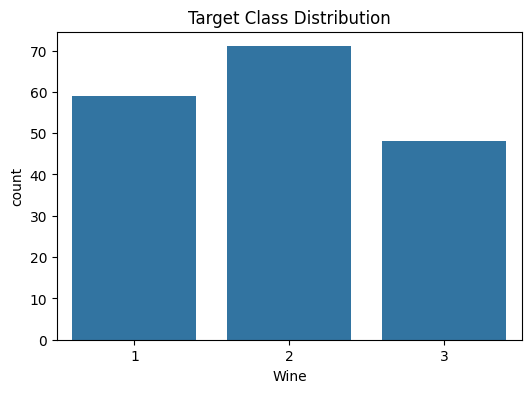

In [7]:
print("Target Distribution:\n")
print(df['Wine'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='Wine', data=df)
plt.title('Target Class Distribution')
plt.show()

- As illustrated in the chart, the sample counts are not exactly equal:

  Class 2: Highest frequency (approximately 71 samples).

  Class 1: Intermediate frequency (approximately 59 samples).

  Class 3: Lowest frequency (approximately 48 samples).

- While the classes are not perfectly balanced, they are considered roughly balanced.

  The disparity between the classes is not severe (unlike an extreme imbalance like 100 vs. 5 samples). Therefore, the model is unlikely to encounter serious bias issues or ignore the minority class.

- Because of these slight variations in count, Section 2 of the exercise emphasizes using stratify=y. This ensures that these specific class proportions (approximately 40%, 33%, and 27%) are preserved in both the training and testing sets, guaranteeing a fair model evaluation.

### Statistics for Alcohol, Flavanoids, Color_Intensity

In [8]:
features_to_check = ['Alcohol', 'Flavanoids', 'Color.int']
print("Statistics for Selected Features:\n")
display(df[features_to_check].describe())

Statistics for Selected Features:



,Alcohol,Flavanoids,Color.int
count,178.000000,178.000000,178.000000
mean,13.000618,2.029270,5.058090
std,0.811827,0.998859,2.318286
min,11.030000,0.340000,1.280000
25%,12.362500,1.205000,3.220000
50%,13.050000,2.135000,4.690000
75%,13.677500,2.875000,6.200000
max,14.830000,5.080000,13.000000


### Pairplot

We select a few columns to avoid a massive plot, including the Target for coloring

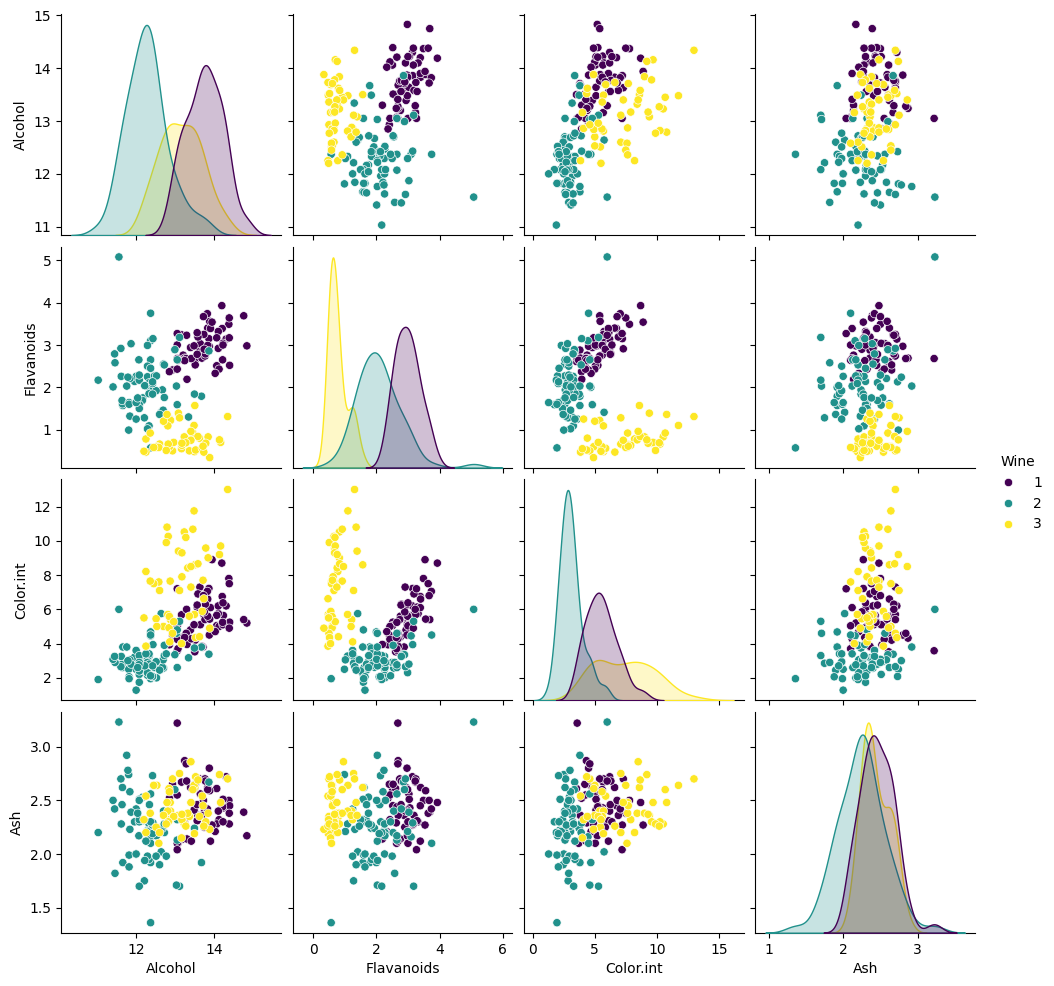

In [9]:
cols_for_plot = ['Alcohol', 'Flavanoids', 'Color.int', 'Ash', 'Wine']
sns.pairplot(df[cols_for_plot], hue='Wine', palette='viridis')
plt.show()

## Section 2: Preparation for Modeling

**Goal: Split data, normalize features, and build a base model.**

### Define X (features) and y (target)


In [10]:
X = df.drop('Wine', axis=1)
y = df['Wine']

### Train/Test Split (80/20) with stratify

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

Why use stratify?
- Using stratify=y ensures that the proportion of classes (e.g., Wine Type A, B, C) remains the same in both the training and testing sets as it is in the original dataset. This is crucial in multi-class classification to prevent a scenario where the test set accidentally ends up with zero examples of a specific minority class.

### Standardization

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Why Standardize?  
- KNN is a distance-based algorithm (it calculates the distance between points). If one feature has a range of 0–1000 and another has a range of 0–1, the feature with the larger range will dominate the distance calculation, making the model biased. Standardization (scaling to mean=0, std=1) gives all features equal importance.

### Base KNN Model (k=5, Euclidean)

In [13]:
knn_base = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_base.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


### Calculate Accuracy

In [14]:
y_pred_base = knn_base.predict(X_test_scaled)
print(f"Base KNN Accuracy: {accuracy_score(y_test, y_pred_base):.4f}")

Base KNN Accuracy: 0.9722


## Section 3: Pipeline & Grid Search

**Goal: Automate the workflow and find the best hyperparameters.**

### Create Pipeline

In [15]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

### Define Hyperparameters for GridSearch

In [16]:
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

### Run GridSearch with cv=5 and scoring='accuracy'

In [17]:
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)  

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'knn__metric': ['euclidean', 'manhattan'], 'knn__n_neighbors': [3, 5, ...], 'knn__weights': ['uniform', 'distance']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


### Report Results

In [18]:
print("Grid Search Results:\n")
print(f"Best Parameters: {grid.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid.best_score_:.4f}")

Grid Search Results:

Best Parameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 9, 'knn__weights': 'uniform'}
Best Cross-Validation Accuracy: 0.9862


## Section 4: Evaluation & Analysis

**Goal: Evaluate the optimized model and analyze errors.**

Confusion Matrix Plot

### Evaluate best model on Test Set

In [19]:
best_model = grid.best_estimator_
y_pred_opt = best_model.predict(X_test)

print("\nTest Set Evaluation:\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred_opt):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_opt))
print("\nCconfusion matrix:")
print(confusion_matrix(y_test, y_pred_opt))



Test Set Evaluation:

Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


Cconfusion matrix:
[[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]


### Confusion Matrix Plot

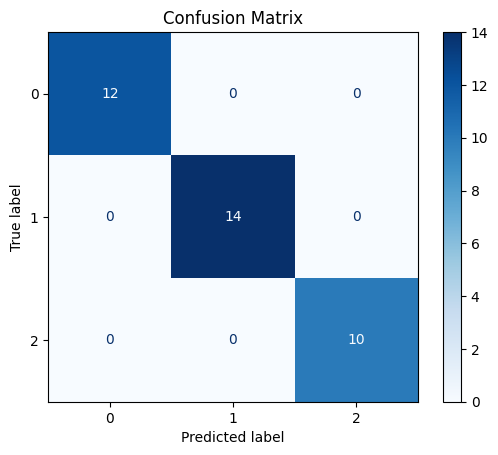

In [20]:
cm = confusion_matrix(y_test, y_pred_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

### K vs Accuracy Plot
 We verify training vs test accuracy to spot overfitting/underfitting

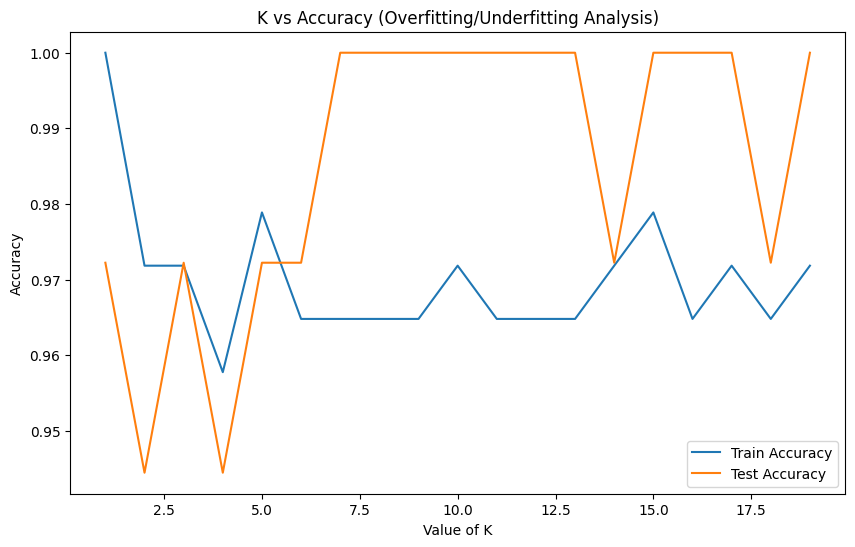

In [21]:
k_values = range(1, 20)
train_scores = []
test_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_scores.append(knn.score(X_train_scaled, y_train))
    test_scores.append(knn.score(X_test_scaled, y_test))

plt.figure(figsize=(10, 6))
plt.plot(k_values, train_scores, label='Train Accuracy')
plt.plot(k_values, test_scores, label='Test Accuracy')
plt.xlabel('Value of K')
plt.ylabel('Accuracy')
plt.legend()
plt.title('K vs Accuracy (Overfitting/Underfitting Analysis)')
plt.show()

### K Value Analysis for KNN

Based on the relationship between the **Train Accuracy** (blue line) and the **Test Accuracy** (orange line) shown in your plot, we can identify the following behaviors:

#### 1. Overfitting (High Variance)

Overfitting occurs when the model performs significantly better on the training data than on the unseen test data. The model has essentially memorized the training set, including its noise.

* **Behavior on Plot:** A large gap exists between the Train Accuracy (blue) and Test Accuracy (orange), where the blue line is much higher.
* **Result:**
    * The model shows slight overfitting at **low values of $k$** (e.g., $k=1$ and  $k=3$). At $k=1$, Train Accuracy is $1.00$ while Test Accuracy drops to approximately $0.97$, indicating the model is too sensitive to local data points.

#### 2. Underfitting (High Bias)

Underfitting occurs when the model is too simple to capture the underlying patterns in the data, leading to poor performance on both training and test sets.

* **Behavior on Plot:** Both the Train and Test Accuracy lines drop significantly toward the bottom of the graph.
* **Result:**
    * The data shows a tendency toward underfitting begins at **high values of $k$** (e.g., beyond $k=17$). The Test Accuracy becomes more volatile, and overall performance degrades (e.g., the drop observed around $k=18$).

#### 3. Optimal Range (Good Generalization)

The optimal range is where the Test Accuracy (orange line) is highest and stable, showing that the model generalizes well to unseen data.

* **Optimal Range:** The model achieves the highest and most consistent performance between **$k=5$ and $k=15$**. In this range, both Train Accuracy and Test Accuracy are consistently **$1.00$** (or very near $1.00$).
 

---

### Euclidean vs. Manhattan:
 - Euclidean ($L2$ norm): The "straight line" distance. Works well for standard continuous data.
 - Manhattan ($L1$ norm): The "city block" distance (sum of absolute differences). Manhattan is sometimes better in high-dimensional spaces (sparse data) because Euclidean distance loses meaning as dimensions increase (Curse of Dimensionality).

In [22]:
# Column names (aligned with your DataInfo output)
column_names_fixed = [
    'Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols',
    'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int',
    'Hue', 'OD', 'Proline'
]

# Creating three new hypothetical samples
new_samples_data = [
    # Sample 1: Similar to Class 1    
    [14.0, 1.5, 2.4, 15.0, 105, 3.5, 2.2, 0.20, 2.1, 5.0, 1.3, 4.0, 1200],

    # Sample 2: Similar to Class 2
    [12.5, 1.4, 2.3, 20.0, 87, 2.8, 2.0, 0.25, 1.7, 2.5, 1.05, 3.5, 800],

    # Sample 3: Similar to Class 3
    [13.0, 3.0, 2.5, 24.0, 85, 1.8, 0.5, 0.50, 1.0, 7.5, 0.7, 1.5, 500]

]

new_samples_df = pd.DataFrame(new_samples_data, columns=column_names_fixed)

# Prediction
predictions = best_model.predict(new_samples_df)

results_df = new_samples_df.copy()
results_df['Predicted_Wine_Type'] = predictions

print("Optimized Model Predictions on New Samples\n")
print(results_df[['Alcohol', 'Flavanoids', 'Color.int', 'Predicted_Wine_Type']])


Optimized Model Predictions on New Samples

   Alcohol  Flavanoids  Color.int  Predicted_Wine_Type
0     14.0         2.2        5.0                    1
1     12.5         2.0        2.5                    2
2     13.0         0.5        7.5                    3


## Section 5: Final Analysis

**Goal: Feature importance, suggestions, and summary.**

### Correlation Matrix

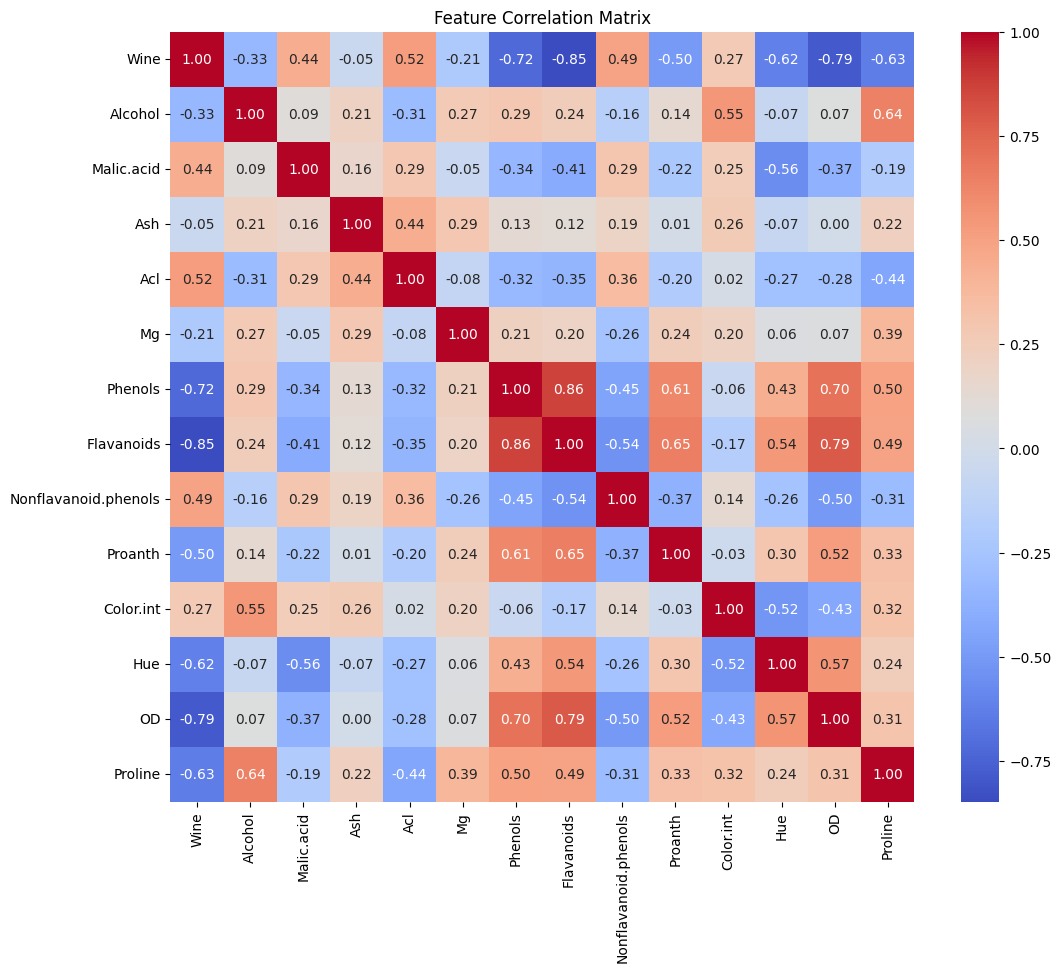

In [23]:
plt.figure(figsize=(12, 10))
# Calculate correlation between all features and the target
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

### 1. Which features play the most important role in distinguishing wine types? Justify your answer using the correlation matrix.

Based on the correlation matrix, several features show strong relationships with the wine class label (Wine). Features with higher absolute correlation values contribute more to distinguishing wine types. The most influential features are:

1- Flavanoids (correlation ≈ –0.85)

This variable shows the strongest correlation with wine type. Its high absolute value indicates substantial variation across wine classes, making it the most influential feature for classification.

2- OD280/OD315 (OD) (correlation ≈ –0.79)

This feature also demonstrates a strong negative correlation with the wine label. Its relationship with other phenolic compounds reinforces its role as a major indicator of wine type.

3- Phenols (correlation ≈ –0.72)

Total phenols contribute meaningfully to distinguishing wine categories. Their strong correlation, as well as their biological relevance to wine composition, make them an important predictor.

4- Hue (correlation ≈ –0.62)

Hue provides color-based information that varies consistently across wine classes, contributing significantly to separation in the feature space.

5- Proline (correlation ≈ –0.63)

Proline, an amino acid linked to grape quality, shows strong correlation with wine type and provides additional separation between classes.


 Features such as Flavanoids, OD280/OD315, Phenols, Hue, and Proline play the most important roles in distinguishing wine types. Their relatively high absolute correlation values in the matrix indicate strong and systematic differences across wine classes, making them key predictors in the classification process.

---

### 2. If you need to build a model that is faster but still reasonably accurate, what approach would you recommend?

To achieve faster model performance while maintaining acceptable accuracy, dimensionality reduction techniques can be applied. One effective approach is PCA (Principal Component Analysis), which projects the data onto a lower-dimensional space while preserving most of the variance. Alternatively, removing low-importance or highly redundant features can reduce computational cost and potentially improve generalization. Both methods decrease model complexity and significantly speed up prediction time.

In [24]:
log_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_logreg = log_reg.predict(X_test_scaled)
print("Classification Report: Logistic Regression")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logreg)) 
print("Cconfusion matrix:")
print(confusion_matrix(y_test, y_pred_logreg))

Classification Report: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       0.93      1.00      0.97        14
           3       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36

Cconfusion matrix:
[[12  0  0]
 [ 0 14  0]
 [ 0  1  9]]


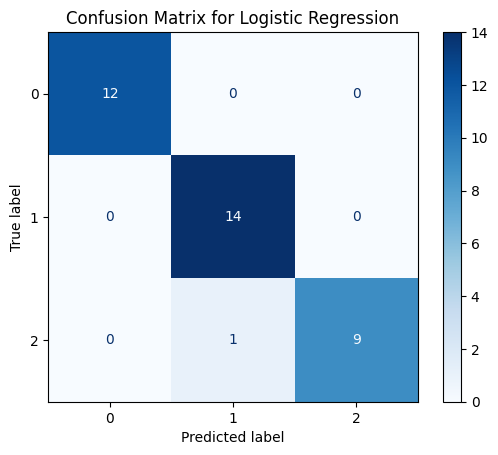

In [25]:
cm = confusion_matrix(y_test, y_pred_logreg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix for Logistic Regression")
plt.show()

### 3. Compare the performance of KNN with a simpler model (e.g., Logistic Regression).

To evaluate how KNN performs relative to a simpler, parametric model, we compare both algorithms on the same test set using accuracy, precision, recall, F1-score, and confusion matrices.

- Logistic Regression – Performance Summary

  - Logistic Regression achieves strong overall performance:

    - Accuracy: 0.97

    - Macro F1-score: 0.97

    - Class-level performance:

       Class 1: perfect classification

       Class 2: perfect recall, slightly lower precision

       Class 3: small misclassification (1 sample predicted as Class 2)

    - Confusion Matrix shows:

       Only one misclassification (Class 3 → Class 2)

**This indicates that Logistic Regression is effective but limited by its linear decision boundary, which may not fully capture the nonlinear structure of this dataset.**

- KNN – Performance Summary

  - KNN yields perfect performance on the same test set:

    - Accuracy: 1.00

    - Precision/Recall/F1: 1.00 for all classes

    - Confusion Matrix:

      Zero misclassifications across all classes

**This demonstrates that KNN models the underlying data structure extremely well, likely because the wine dataset has well-separated clusters, which KNN can exploit effectively.**

KNN provides superior predictive performance on this dataset, achieving 100% accuracy, while Logistic Regression performs very well but not perfectly.
However, Logistic Regression still offers advantages in terms of speed, interpretability, and scalability, making it a strong baseline model.
KNN is preferable when the dataset is moderately sized and classes are well separated, as in this case.

---

### 4. What is the main limitation of the KNN algorithm? How can it be optimized for larger-scale projects?

The main limitation of KNN is its high computational cost at prediction time, since it must compute distances to all training samples. This makes it unsuitable for large datasets.

To optimize KNN for larger applications, several strategies can be used:

- Applying dimensionality reduction (e.g., PCA)

- Using efficient data structures such as KD-Trees or Ball Trees

- Reducing the size of the training set through sampling or prototype selection techniques

- Normalizing features to improve distance calculations

These methods can significantly reduce inference time and improve scalability.

---

### 5. Summarize the following:
- **Strengths of KNN**

   - Simple to understand and implement

   - Non-parametric; makes no assumptions about data distribution

   - Performs well on small to medium-sized datasets

   - Effective for problems with well-separated classes

- **Weaknesses of KNN**

   - Slow prediction time due to distance calculations

   - Sensitive to irrelevant or unscaled features

   - Performance degrades with high-dimensional data (curse of dimensionality)

   - Memory-intensive, as training data must be stored

- **Situations where KNN is appropriate**

   - When the dataset is small to moderately sized

   - When data is low-dimensional and well-scaled

   - When decision boundaries are non-linear

   - When interpretability of local neighbors is important